# Prepare the enviroment

In [1]:
LOCAL = False

In [2]:
if not LOCAL:
    import sys
    sys.path.insert(1, '/kaggle/input/datasets/dominikaboguszewska/sigk-p4-bunny-v1')

In [3]:
if not LOCAL:
    !pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 11.7 MB/s eta 0:00:00 0:00:01


In [4]:
import os
import json
import trimesh
import datetime

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from pathlib import Path

if LOCAL:
    from bunny.utils import load_mesh, pointcloud_to_mesh, visualize_transition, visualize_transition_3d, interpolate_pointclouds, standardize_pointcloud, load_mesh_pointcloud
    from bunny.model import BunnyToTeapotVectorField, load_model
    from evaluate import evaluate_all
if not LOCAL:
    from utils import load_mesh, pointcloud_to_mesh, visualize_transition, visualize_transition_3d, interpolate_pointclouds, standardize_pointcloud, load_mesh_pointcloud
    from model import BunnyToTeapotVectorField, load_model
    from evaluate import evaluate_all

In [5]:
def get_timestamp() -> str:
    ct = datetime.datetime.now()

    return ct.strftime("%Y-%m-%d_%H-%M-%S")

In [6]:
if LOCAL:
    PROJ_ROOT = Path(os.getcwd()).parents[0]

    MODELS_DIR = PROJ_ROOT / "modele"
    BUNNY_OBJECT_PATH = MODELS_DIR / "bunny.obj"
    TEAPOT_OBJECT_PATH = MODELS_DIR / "teapot.obj"

    BUNNY_PIPELINE_DIR = PROJ_ROOT / "bunny"
    RUNS_DIR = BUNNY_PIPELINE_DIR / "runs"
    RUNS_DIR.mkdir(parents=True, exist_ok=True)
else:
    PROJ_ROOT = Path("/kaggle/input/datasets/dominikaboguszewska/sigk-p4-bunny-v1")
    RUNS_DIR = Path("/kaggle/working/")

    BUNNY_OBJECT_PATH = PROJ_ROOT / "bunny.obj"
    TEAPOT_OBJECT_PATH = PROJ_ROOT / "teapot.obj"

CURRENT_RUN_DIR = RUNS_DIR / get_timestamp()
CURRENT_RUN_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINTS_DIR = RUNS_DIR / "checkpoints"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CURRENT_RUN_DIR / "best_model.pt"

print(f"Project root: {PROJ_ROOT} (exists: {PROJ_ROOT.exists()}) \n")
print(f"Bunny object: {BUNNY_OBJECT_PATH} (exists: {BUNNY_OBJECT_PATH.exists()}) \n")
print(f"Teapot object: {TEAPOT_OBJECT_PATH} (exists: {TEAPOT_OBJECT_PATH.exists()}) \n")
print(f"Runs dir: {RUNS_DIR} (exists: {RUNS_DIR.exists()}) \n")
print(f"Current run dir: {CURRENT_RUN_DIR} (exists: {CURRENT_RUN_DIR.exists()}) \n")
print(f"Checkpoints dir: {CHECKPOINTS_DIR} (exists: {CHECKPOINTS_DIR.exists()}) \n")

Project root: /kaggle/input/datasets/dominikaboguszewska/sigk-p4-bunny-v1 (exists: True) 

Bunny object: /kaggle/input/datasets/dominikaboguszewska/sigk-p4-bunny-v1/bunny.obj (exists: True) 

Teapot object: /kaggle/input/datasets/dominikaboguszewska/sigk-p4-bunny-v1/teapot.obj (exists: True) 

Runs dir: /kaggle/working (exists: True) 

Current run dir: /kaggle/working/2026-05-12_20-42-21 (exists: True) 

Checkpoints dir: /kaggle/working/checkpoints (exists: True) 



In [7]:
N_POINTS = 2048
DATASET_SIZE = 10000

VAL_RATIO = 0.2

BATCH_SIZE = 16
NUM_WORKERS = 4

LOCAL_FEAT_DIMS = [64, 128]
CONTEXT_FEAT_DIMS = [256, 512]
HEAD_DIMS = [256, 128]
DROPOUT = 0.0

EPOCHS = 200
LR = 3e-4
CHECKPOINT = 5

In [8]:
config_path = Path(f"{CURRENT_RUN_DIR}/config.json")

config = {
    "n_points": N_POINTS,
    "dataset_size": DATASET_SIZE,
    "val_ratio": VAL_RATIO,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "local_feat_dims": LOCAL_FEAT_DIMS,
    "context_feat_dims": CONTEXT_FEAT_DIMS,
    "head_dims": HEAD_DIMS,
    "dropout": DROPOUT,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "checkpoint_interval": CHECKPOINT,
}

with open(config_path, "w") as f:
    json.dump(config, f, indent=4, sort_keys=True)

In [9]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    print(f"Using device: {DEVICE}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    raise RuntimeError("No GPU available!")

Using device: cuda
GPU name: Tesla T4


In [10]:
device_t = torch.device(DEVICE)
print(f"Device for tensors: {device_t}")

Device for tensors: cuda


# Load the data

In [11]:
def generate_random_rotation() -> np.ndarray:
    q, _ = np.linalg.qr(np.random.randn(3, 3))

    if np.linalg.det(q) < 0:
        q[:, 0] *= -1

    return q.astype(np.float32)

In [12]:
def apply_random_scale(scale_bounds: tuple[float, float] = (0.7, 1.3)) -> float:
    return float(np.random.uniform(*scale_bounds))

In [13]:
class BunnyTeapotDataset(Dataset):
    def __init__(
        self,
        bunny_path: str,
        teapot_path: str,
        n_points: int = 2048,
        dataset_size: int = 10000,
        use_augment: bool = True,
        scale_factor: tuple[float, float] = None,
    ):
        if scale_factor is None:
            scale_factor = (0.75, 1.25)

        self.n_points = n_points
        self.dataset_size = dataset_size
        self.use_augment = use_augment
        self.scale_factor = scale_factor

        self.bunny_mesh = load_mesh(bunny_path)
        self.teapot_target = standardize_pointcloud(
            load_mesh_pointcloud(teapot_path, n_points)
        )

    def __len__(self) -> int:
        return self.dataset_size

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        src_pts, _ = trimesh.sample.sample_surface(self.bunny_mesh, self.n_points)
        src_pts = standardize_pointcloud(src_pts.astype(np.float32))

        if self.use_augment:
            R = generate_random_rotation()
            s = apply_random_scale(self.scale_factor)
            src_pts = (src_pts @ R.T) * s

        return torch.from_numpy(src_pts), torch.from_numpy(self.teapot_target.copy())

In [14]:
dataset = BunnyTeapotDataset(
    bunny_path=str(BUNNY_OBJECT_PATH),
    teapot_path=str(TEAPOT_OBJECT_PATH),
    n_points=N_POINTS,
    dataset_size=DATASET_SIZE,
    use_augment=True,
)

print(f"Dataset initialized with {len(dataset)} samples. Each sample has {N_POINTS} points")

Dataset initialized with 10000 samples. Each sample has 2048 points


In [15]:
source, target = dataset[0]
print(f"Source shape: {source.shape}")
print(f"Target shape: {target.shape}")

Source shape: torch.Size([2048, 3])
Target shape: torch.Size([2048, 3])


In [16]:
val_size = int(len(dataset) * VAL_RATIO)
print(f"Validation set size: {val_size}")

Validation set size: 2000


In [17]:
train_dataset, val_dataset = random_split(dataset, [len(dataset) - val_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train set: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Validation set: {len(val_dataset)} samples, {len(val_loader)} batches")

Train set: 8000 samples, 500 batches
Validation set: 2000 samples, 125 batches


# Model

In [18]:
model = BunnyToTeapotVectorField(
        local_feat_dims=LOCAL_FEAT_DIMS,
        context_feat_dims=CONTEXT_FEAT_DIMS,
        head_dims=HEAD_DIMS,
        dropout=DROPOUT,
    ).to(device_t)

print(f"Model initialized with {sum(p.numel() for p in model.parameters())} parameters.")

Model initialized with 373251 parameters.


# Training

In [19]:
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

In [20]:
def chamfer_distance(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    diff = pred.unsqueeze(2) - target.unsqueeze(1)
    dist_sq = (diff ** 2).sum(dim=-1)

    forward = dist_sq.min(dim=2).values.mean()
    backward = dist_sq.min(dim=1).values.mean()

    return forward + backward

In [21]:
print(f"Training BUNNY → TEAPOT for {EPOCHS} epochs …")

history: dict[str, list[float]] = {
    "train_loss": [],
    "val_loss": [],
    "lr": [],
}

best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for source, target in train_loader:
        source, target = source.to(device_t), target.to(device_t)

        loss = chamfer_distance(model(source), target)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    history["train_loss"].append(train_loss)

    model.eval()
    val_losses = []

    for source, target in val_loader:
        source, target = source.to(device_t), target.to(device_t)

        loss = chamfer_distance(model(source), target)
        val_losses.append(loss.item())

    val_loss = float(np.mean(val_losses))
    history["val_loss"].append(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    history["lr"].append(current_lr)

    scheduler.step()

    print(f"Epoch {epoch}/{EPOCHS}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}, LR={current_lr:.2e}")

    if epoch % CHECKPOINT == 0:
        checkpoint_path = CURRENT_RUN_DIR / f"checkpoint_{epoch}.pt"
        torch.save(model.state_dict(), checkpoint_path)
        print(f"    Saved checkpoint at epoch {epoch}")

    if val_loss < best_val_loss:
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"    Saved best model at epoch {epoch}")

print("Training completed")

Training BUNNY → TEAPOT for 200 epochs …
Epoch 1/200: Train Loss=0.027267, Val Loss=0.006760, LR=3.00e-04
    Saved best model at epoch 1
Epoch 2/200: Train Loss=0.005678, Val Loss=0.004037, LR=3.00e-04
    Saved best model at epoch 2
Epoch 3/200: Train Loss=0.003925, Val Loss=0.003267, LR=3.00e-04
    Saved best model at epoch 3
Epoch 4/200: Train Loss=0.003237, Val Loss=0.002801, LR=3.00e-04
    Saved best model at epoch 4
Epoch 5/200: Train Loss=0.002828, Val Loss=0.002551, LR=3.00e-04
    Saved checkpoint at epoch 5
    Saved best model at epoch 5
Epoch 6/200: Train Loss=0.002567, Val Loss=0.002375, LR=3.00e-04
    Saved best model at epoch 6
Epoch 7/200: Train Loss=0.002366, Val Loss=0.002233, LR=2.99e-04
    Saved best model at epoch 7
Epoch 8/200: Train Loss=0.002236, Val Loss=0.002111, LR=2.99e-04
    Saved best model at epoch 8
Epoch 9/200: Train Loss=0.002118, Val Loss=0.002016, LR=2.99e-04
    Saved best model at epoch 9
Epoch 10/200: Train Loss=0.002041, Val Loss=0.001958, 

In [22]:
history_path = Path(f"{CURRENT_RUN_DIR}/history.json")

with open(history_path, "w") as f:
    json.dump(history, f, indent=4, sort_keys=True)

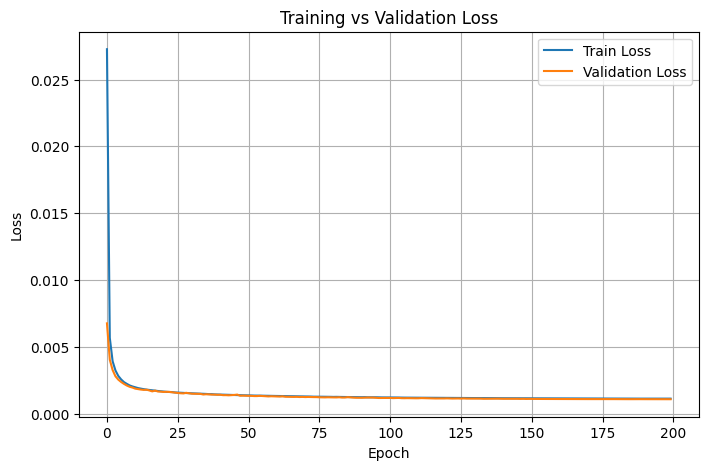

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIR}/loss.png", dpi=300, bbox_inches="tight")

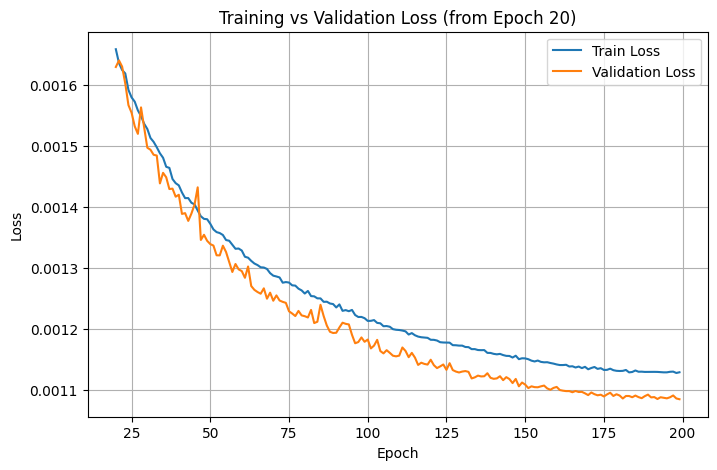

In [24]:
start_epoch = 20

train_loss = history["train_loss"][start_epoch:]
val_loss = history["val_loss"][start_epoch:]

epochs = range(start_epoch, start_epoch + len(train_loss))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training vs Validation Loss (from Epoch {start_epoch})")
plt.legend()
plt.grid(True)

plt.savefig(
    CURRENT_RUN_DIR / f"loss_from_epoch_{start_epoch}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

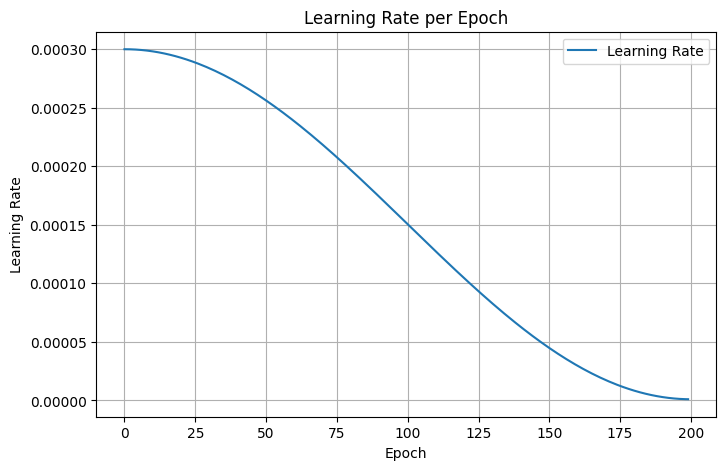

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history["lr"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate per Epoch")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIR}/lr.png", dpi=300, bbox_inches="tight")

# Evaluation

In [26]:
model = load_model(
    BEST_MODEL_PATH,
    local_feat_dims=LOCAL_FEAT_DIMS,
    context_feat_dims=CONTEXT_FEAT_DIMS,
    head_dims=HEAD_DIMS,
    dropout=DROPOUT,
    device=DEVICE
)

In [27]:
def normalize_pointcloud(points: np.ndarray) -> np.ndarray:
    points = points - points.mean(axis=0)
    scale = np.linalg.norm(points, axis=1).max()

    return points / scale

In [28]:
def transform_mesh(obj_path: Path, model, device, n_points: int) -> np.ndarray:
    pts = normalize_pointcloud(load_mesh_pointcloud(obj_path, n_points))
    tensor = torch.from_numpy(pts).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(tensor).squeeze(0).cpu().numpy()

    return pred

In [29]:
model.eval()

teapot_mesh = load_mesh(TEAPOT_OBJECT_PATH)

pred_points = transform_mesh(BUNNY_OBJECT_PATH, model, DEVICE, N_POINTS)
pred_mesh = pointcloud_to_mesh(pred_points)

metrics = evaluate_all(pred_mesh, teapot_mesh, n_points=N_POINTS, resolution=64)
json.dump(metrics, open(CURRENT_RUN_DIR / "metrics.json", "w"), indent=4)

In [30]:
print("=== Bunny flow — metrics ===")
print(f"  IoU     : {metrics['iou']:.4f}")
print(f"  Dice    : {metrics['dice']:.4f}")
print(f"  Chamfer : {metrics['chamfer']:.6f}")

=== Bunny flow — metrics ===
  IoU     : 0.7057
  Dice    : 0.8275
  Chamfer : 3.219213


# Visualisation

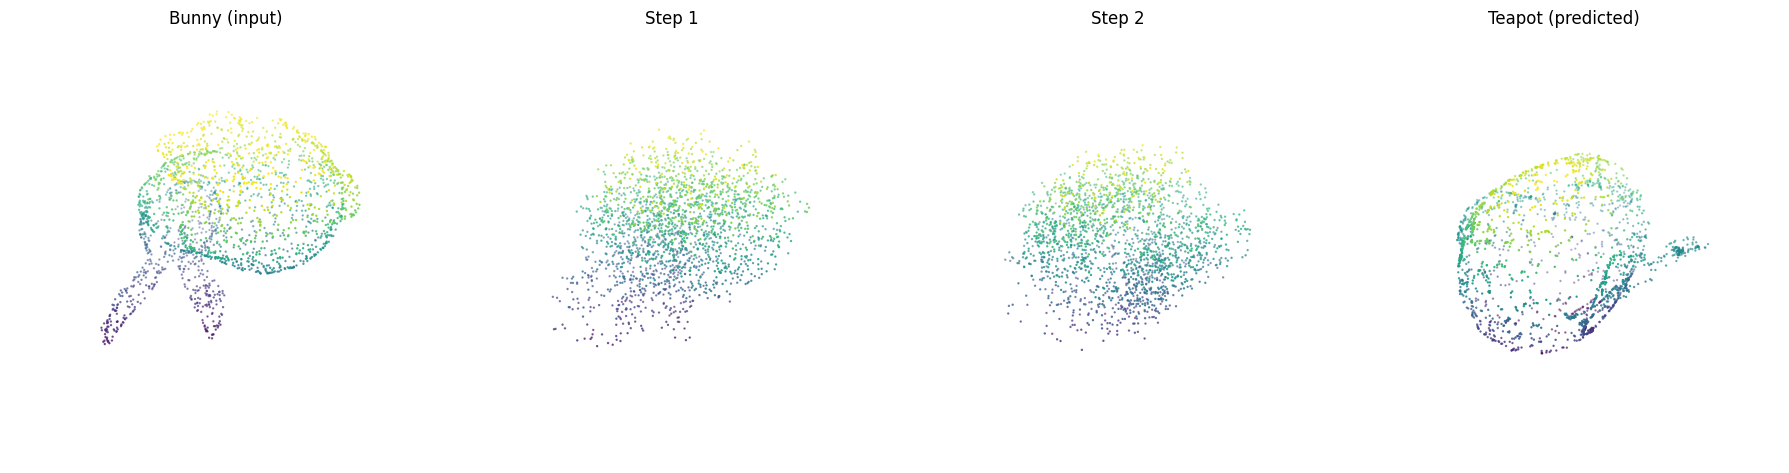

In [31]:
model.eval()

src_pts = normalize_pointcloud(load_mesh_pointcloud(BUNNY_OBJECT_PATH, N_POINTS))
pred_pts = transform_mesh(BUNNY_OBJECT_PATH, model, DEVICE, N_POINTS)

steps = interpolate_pointclouds(src_pts, pred_pts, steps=4)

visualize_transition(
    steps,
    titles=["Bunny (input)", "Step 1", "Step 2", "Teapot (predicted)"]
)

In [32]:
visualize_transition_3d(
    steps,
    titles=["Bunny (input)", "Step 1", "Step 2", "Teapot (predicted)"]
)

# Download the results

In [33]:
import os
import subprocess
from IPython.display import FileLink, display

def download_file(path, download_file_name):
    os.chdir('/kaggle/working/')
    zip_name = f"/kaggle/working/{download_file_name}.zip"
    command = f"zip {zip_name} {path} -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)

    if result.returncode != 0:
        print("Unable to run zip command!")
        print(result.stderr)

        return

    display(FileLink(f'{download_file_name}.zip'))

In [34]:
if not LOCAL:
    download_file(CURRENT_RUN_DIR, f"SIGK_p4_bunny_{CURRENT_RUN_DIR.name}")

/kaggle/working/SIGK_p4_bunny_2026-05-12_20-42-21.zip